# ZGT Ground-Truth Component Boxes to MedSAM Segmentation

This notebook is a segmentation-only MedSAM pipeline for the ZGT test set.

It uses the dependency-injection dataset utilities from `utils/dep_injection_util.py`:

- `BaseDataset` for dataset wiring
- `PngLoader` for loading `img.jpg` and `mask.png`
- `ConnectedComponentsBBoxFromMask` for extracting one box per connected mass component

Important verification: the original `BBoxFromMask` returns **one enclosing box** around all nonzero mask pixels. For masks with multiple disconnected masses, that can produce one oversized prompt. The notebook therefore uses `ConnectedComponentsBBoxFromMask`, which extracts one prompt box per connected component.

Pipeline:

1. Load ZGT test cases from the VersaMammo-format folder.
2. Load images and GT masks through `BaseDataset` dependency injection.
3. Extract one GT box per connected component in the mask.
4. Resize images, masks, and all boxes to `1024 x 1024` for MedSAM.
5. Run MedSAM once per GT component box.
6. Union prompt masks per image.
7. Compute Dice and save overlay visualizations.

In [32]:
from pathlib import Path
import json
import sys
from peft import LoraConfig, get_peft_model
import monai
import tqdm
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from skimage import io
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader

In [2]:
# -------------------------
# Configuration
# -------------------------
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "pipelines_and_experiments":
    PROJECT_ROOT = PROJECT_ROOT.parent

MEDSAM_ROOT = PROJECT_ROOT / "MedSAM"
MEDSAM_SEGMENTATION_DIR = MEDSAM_ROOT / "notebooks" / "segmentation"
VERSAMAMMO_ROOT = PROJECT_ROOT / "VersaMammo"
DETECTION_METRICS_DIR = VERSAMAMMO_ROOT / "downstream" / "Detection" / "metrics"
DATA_ROOT = VERSAMAMMO_ROOT / "datapre" / "segdetdata"

DATASET_PREFIX = "ZGT_VersaMammo"
TEST_DATASET = None  # None = use fold with best detection map_50 if available. Or set e.g. "ZGT_VersaMammo_fold4".
BEST_METRIC = "map_50"

DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"
MEDSAM_CHECKPOINT = MEDSAM_ROOT / "work_dir" / "medsam_vit_b.pth"
OUTPUT_ROOT = PROJECT_ROOT / "pipelines_and_experiments" / "lora_medsam_from_zgt_gt_component_boxes"

MEDSAM_IMAGE_SIZE = (1024, 1024)
MIN_COMPONENT_AREA = 1
BBOX_PADDING = 0
BBOX_CONNECTIVITY = 2  # 2 = 8-neighborhood; 1 = 4-neighborhood
MASK_THRESHOLD = 0.5
BATCH_SIZE = 1

print(f"Project root: {PROJECT_ROOT}")
print(f"CUDA available: {torch.cuda.is_available()} | device: {DEVICE}")

Project root: /export/home/rstanciu/FM_thesis_Razvan/FM_thesis
CUDA available: True | device: cuda:0


In [3]:
# Imports from this repo and from MedSAM.
# PROJECT_ROOT must be on sys.path so `utils.dep_injection_util` resolves to FM_thesis/utils.
for path in [PROJECT_ROOT, MEDSAM_ROOT, MEDSAM_SEGMENTATION_DIR]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from MedSAM.segment_anything import sam_model_registry
from utils.dep_injection_util import (
    BaseDataset,
    PngLoader,
    ConnectedComponentsBBoxFromMask,
)

In [4]:
def load_json(path: Path):
    with open(path) as f:
        return json.load(f)


def choose_best_dataset(metrics_dir: Path, dataset_prefix: str, metric: str) -> str:
    candidates = []
    for metrics_path in sorted(metrics_dir.glob(f"{dataset_prefix}_fold*/test_metrics.json")):
        metrics = load_json(metrics_path)
        if metric in metrics:
            candidates.append((float(metrics[metric]), metrics_path.parent.name))
    if not candidates:
        return f"{dataset_prefix}_fold0"
    candidates.sort(reverse=True)
    print("Available detection folds:")
    for value, fold_name in candidates:
        print(f"  {fold_name}: {metric}={value:.4f}")
    return candidates[0][1]


DATASET_NAME = TEST_DATASET or choose_best_dataset(DETECTION_METRICS_DIR, DATASET_PREFIX, BEST_METRIC)
TRAIN_ROOT = DATA_ROOT / DATASET_NAME / "Train"
TEST_ROOT = DATA_ROOT / DATASET_NAME / "Test"
EVAL_ROOT = DATA_ROOT / DATASET_NAME / "Eval"
OUT_DIR = OUTPUT_ROOT / DATASET_NAME
MASK_OUT_DIR = OUT_DIR / "pred_masks"
OVERLAY_OUT_DIR = OUT_DIR / "overlays"
WEIGHTS_OUT_DIR= OUT_DIR / "weights"
METRICS_OUT = OUT_DIR / "medsam_gt_component_prompt_metrics.csv"
SUMMARY_OUT = OUT_DIR / "medsam_gt_component_prompt_summary.json"

print(f"Selected test dataset: {DATASET_NAME}")
print(f"Test root: {TEST_ROOT}")
print(f"Output root: {OUT_DIR}")

Available detection folds:
  ZGT_VersaMammo_fold4: map_50=0.5577
  ZGT_VersaMammo_fold3: map_50=0.4485
  ZGT_VersaMammo_fold1: map_50=0.4166
  ZGT_VersaMammo_fold2: map_50=0.3688
Selected test dataset: ZGT_VersaMammo_fold4
Test root: /export/home/rstanciu/FM_thesis_Razvan/FM_thesis/VersaMammo/datapre/segdetdata/ZGT_VersaMammo_fold4/Test
Output root: /export/home/rstanciu/FM_thesis_Razvan/FM_thesis/pipelines and experiments/lora_medsam_from_zgt_gt_component_boxes/ZGT_VersaMammo_fold4


In [5]:
def collect_versamammo_cases(root):
    """Collector for BaseDataset: one sample per VersaMammo test case folder."""
    root = Path(root)
    samples = []
    for case_dir in sorted(p for p in root.iterdir() if p.is_dir()):
        image_path = case_dir / "img.jpg"
        mask_path = case_dir / "mask.png"
        if not image_path.exists():
            continue
        if not mask_path.exists():
            raise FileNotFoundError(f"Missing mask.png for segmentation GT: {case_dir}")
        samples.append({
            "image_path": image_path,
            "mask_path": mask_path,
            "case_id": case_dir.name,
        })
    return samples

In [30]:
class MedSAM(torch.nn.Module):
    def __init__(
        self,
        image_encoder,
        mask_decoder,
        prompt_encoder,
    ):
        super().__init__()
        self.image_encoder = image_encoder
        self.mask_decoder = mask_decoder
        self.prompt_encoder = prompt_encoder
        # freeze prompt encoder
        for param in self.prompt_encoder.parameters():
            param.requires_grad = False

    def forward(self, image, box):
        image_embedding = self.image_encoder(image)  # (B, 256, 64, 64)
        # do not compute gradients for prompt encoder
        with torch.no_grad():
            box_torch = torch.as_tensor(box, dtype=torch.float32, device=image.device)
            if len(box_torch.shape) == 2:
                box_torch = box_torch[:, None, :]  # (B, 1, 4)

            sparse_embeddings, dense_embeddings = self.prompt_encoder(
                points=None,
                boxes=box_torch,
                masks=None,
            )
        low_res_masks, _ = self.mask_decoder(
            image_embeddings=image_embedding,  # (B, 256, 64, 64)
            image_pe=self.prompt_encoder.get_dense_pe(),  # (1, 256, 64, 64)
            sparse_prompt_embeddings=sparse_embeddings,  # (B, 2, 256)
            dense_prompt_embeddings=dense_embeddings,  # (B, 256, 64, 64)
            multimask_output=False,
        )
        ori_res_masks = F.interpolate(
            low_res_masks,
            size=(image.shape[2], image.shape[3]),
            mode="bilinear",
            align_corners=False,
        )
        
        return ori_res_masks

In [7]:
class MedSAMPreprocess:
    """Convert BaseDataset numpy sample into tensors and scale boxes to MedSAM size."""

    def __init__(self, size=(1024, 1024)):
        self.size = tuple(size)

    def __call__(self, sample):
        image = sample["image"]
        mask = sample["mask"]
        boxes = sample["bbox"]

        if image.ndim == 3:
            image = image[..., 0]
        if mask.ndim == 3:
            mask = mask[..., 0]

        old_h, old_w = image.shape[:2]
        new_h, new_w = self.size

        image = image.astype(np.float32)
        image = (image - image.min()) / max(float(image.max() - image.min()), 1e-8)
        image_t = torch.from_numpy(image).float().unsqueeze(0).repeat(3, 1, 1)
        image_t = F.interpolate(image_t.unsqueeze(0), size=self.size, mode="bilinear", align_corners=False).squeeze(0)

        mask_t = torch.from_numpy((mask > 0).astype(np.uint8)).float().unsqueeze(0)
        mask_t = F.interpolate(mask_t.unsqueeze(0), size=self.size, mode="nearest").squeeze(0).to(torch.uint8)

        if boxes is None:
            box_t = torch.zeros((0, 4), dtype=torch.float32)
        else:
            box_arr = np.asarray(boxes, dtype=np.float32).reshape(-1, 4)
            box_arr[:, [0, 2]] *= new_w / old_w
            box_arr[:, [1, 3]] *= new_h / old_h
            box_t = torch.from_numpy(box_arr).float()

        sample["image"] = image_t
        sample["mask"] = mask_t
        sample["bbox"] = box_t
        sample["original_size"] = (old_h, old_w)
        sample["resized_size"] = self.size
        return sample

In [8]:
def mammo_collate_fn(batch):
    return {
        "image": torch.stack([sample["image"] for sample in batch], dim=0),
        "mask": torch.stack([sample["mask"] for sample in batch], dim=0),
        "bbox": [sample["bbox"] for sample in batch],
        "label": torch.stack([sample["label"] for sample in batch], dim=0),
        "case_id": [sample.get("case_id") for sample in batch],
        "image_path": [sample.get("image_path") for sample in batch],
        "mask_path": [sample.get("mask_path") for sample in batch],
    }


loader = PngLoader(dtype=np.uint8, mode="L")
bbox_generator = ConnectedComponentsBBoxFromMask(
    annotation_threshold=0.5,
    min_mask_area=MIN_COMPONENT_AREA,
    bbox_padding=BBOX_PADDING,
    connectivity=BBOX_CONNECTIVITY,
    allow_empty_mask=True,
)

zgt_train_dataset = BaseDataset(
    root=TRAIN_ROOT,
    file_collector=collect_versamammo_cases,
    format_loader=loader,
    bbox_generator=bbox_generator,
    transforms=MedSAMPreprocess(MEDSAM_IMAGE_SIZE),
    split="all",
    return_metadata=False,
)


zgt_eval_dataset = BaseDataset(
    root=EVAL_ROOT,
    file_collector=collect_versamammo_cases,
    format_loader=loader,
    bbox_generator=bbox_generator,
    transforms=MedSAMPreprocess(MEDSAM_IMAGE_SIZE),
    split="all",
    return_metadata=False,
)


zgt_test_dataset = BaseDataset(
    root=TEST_ROOT,
    file_collector=collect_versamammo_cases,
    format_loader=loader,
    bbox_generator=bbox_generator,
    transforms=MedSAMPreprocess(MEDSAM_IMAGE_SIZE),
    split="all",
    return_metadata=False,
)





zgt_train_loader = DataLoader(
    zgt_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    collate_fn=mammo_collate_fn,
)

zgt_eval_loader = DataLoader(
    zgt_eval_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    collate_fn=mammo_collate_fn,
)



zgt_test_loader = DataLoader(
    zgt_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    collate_fn=mammo_collate_fn,
)

print(f"Loaded {len(zgt_train_loader)} ZGT train images")

Loaded 99 ZGT train images


In [9]:
def dice_score(pred_mask: torch.Tensor, gt_mask: torch.Tensor) -> float:
    pred = pred_mask.bool()
    gt = gt_mask.bool()
    denom = pred.sum() + gt.sum()
    if denom.item() == 0:
        return 1.0
    return float((2 * (pred & gt).sum() / denom).item())



def run_medsam_for_sample(model, image: torch.Tensor, boxes: torch.Tensor):
    H, W = image.shape[-2:]
    if boxes is None or len(boxes) == 0:
        return torch.zeros((1, H, W), dtype=torch.uint8, device="cpu"), []

    image_batch = image.unsqueeze(0).to(DEVICE)
    img_embed = model.image_encoder(image_batch)

    prompt_masks = []
    for box in boxes.to(DEVICE):
        pred = medsam_inference_single(
            medsam_model=model,
            img_embed=img_embed,
            box_1024=box,
            H=H,
            W=W,
            threshold=MASK_THRESHOLD,
        )
        prompt_masks.append(pred.squeeze(0).to(torch.uint8).cpu())

    union = torch.zeros_like(prompt_masks[0])
    for mask in prompt_masks:
        union = torch.logical_or(union.bool(), mask.bool()).to(torch.uint8)
    return union, prompt_masks

In [10]:
def to_display_image(image_tensor: torch.Tensor) -> np.ndarray:
    img = image_tensor.detach().cpu().permute(1, 2, 0).numpy()
    img = (img - img.min()) / max(float(img.max() - img.min()), 1e-8)
    return img


def overlay_result(image_tensor, gt_mask, pred_mask, boxes, title, out_path):
    image = to_display_image(image_tensor)
    gt = gt_mask.detach().cpu().squeeze().numpy().astype(bool)
    pred = pred_mask.detach().cpu().squeeze().numpy().astype(bool)

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(image, cmap="gray")

    gt_rgba = np.zeros((*gt.shape, 4), dtype=np.float32)
    gt_rgba[..., 1] = 1.0
    gt_rgba[..., 3] = gt * 0.35
    ax.imshow(gt_rgba)

    pred_rgba = np.zeros((*pred.shape, 4), dtype=np.float32)
    pred_rgba[..., 0] = 1.0
    pred_rgba[..., 3] = pred * 0.35
    ax.imshow(pred_rgba)

    for i, box in enumerate(boxes.detach().cpu().numpy() if boxes is not None else []):
        x1, y1, x2, y2 = box.tolist()
        rect = plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor="yellow", linewidth=1.5)
        ax.add_patch(rect)
        ax.text(x1, max(0, y1 - 4), f"component {i + 1}", color="black", fontsize=8, bbox={"facecolor": "yellow", "alpha": 0.8, "pad": 1})

    ax.set_title(title)
    ax.set_axis_off()
    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_path, bbox_inches="tight", pad_inches=0, dpi=160)
    plt.close(fig)

In [31]:
if not MEDSAM_CHECKPOINT.exists():
    raise FileNotFoundError(
        f"MedSAM checkpoint not found: {MEDSAM_CHECKPOINT}\n"
        "Update MEDSAM_CHECKPOINT in the configuration cell."
    )

print(f"Loading MedSAM checkpoint: {MEDSAM_CHECKPOINT}")
model = sam_model_registry["vit_b"](checkpoint=str(MEDSAM_CHECKPOINT)).to(DEVICE)

sam_model = sam_model_registry["vit_b"](checkpoint=str(MEDSAM_CHECKPOINT))
model = MedSAM(
    image_encoder=sam_model.image_encoder,
    mask_decoder=sam_model.mask_decoder,
    prompt_encoder=sam_model.prompt_encoder,
).to(DEVICE)


print("MedSAM loaded")


config = LoraConfig(
    r=8,
    lora_alpha=8,
    target_modules=["qkv"],
    lora_dropout=0.1,
    bias="none"
)
model = get_peft_model(model, config)
model.print_trainable_parameters()

model.train()

Loading MedSAM checkpoint: /export/home/rstanciu/FM_thesis_Razvan/FM_thesis/MedSAM/work_dir/medsam_vit_b.pth
MedSAM loaded
trainable params: 294,912 || all params: 94,030,384 || trainable%: 0.3136


PeftModel(
  (base_model): LoraModel(
    (model): MedSAM(
      (image_encoder): ImageEncoderViT(
        (patch_embed): PatchEmbed(
          (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
        )
        (blocks): ModuleList(
          (0-11): 12 x Block(
            (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True, bias=True)
            (attn): Attention(
              (qkv): lora.Linear(
                (base_layer): Linear(in_features=768, out_features=2304, bias=True)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.1, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=768, out_features=8, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=8, out_features=2304, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): Param

In [15]:
batch=next(iter(zgt_train_dataset))

print(batch.keys())

dict_keys(['image', 'mask', 'bbox', 'label', 'original_size', 'resized_size'])


In [27]:
def forward_medsam_multi_box_sample(model, image, boxes, device):
    """
    image: (C, H, W)
    boxes: (K, 4) boxes for this image
    returns: union logits, shape (1, H, W)
    """

    if boxes is None or len(boxes) == 0:
        return None

    logits_per_box = []

    for box in boxes:
        # Important: this must return raw logits, NOT thresholded masks

        pred_logits = model(image,box)


        logits_per_box.append(pred_logits)

    logits_per_box = torch.cat(logits_per_box, dim=0)  # (K, 1, H, W) or (K, H, W)

    # differentiable “union-like” aggregation
    union_logits = logits_per_box.max(dim=0, keepdim=True).values

    return union_logits

In [34]:
trainable_params = [
    p for p in model.parameters()
    if p.requires_grad
]

optimizer = torch.optim.AdamW(
    trainable_params,
    lr=1e-4,
    weight_decay=0.01,
)

seg_loss = monai.losses.DiceLoss(sigmoid=True, squared_pred=True, reduction="mean")
# cross entropy loss
ce_loss = torch.nn.BCEWithLogitsLoss(reduction="mean")
start_epoch=0
num_epochs=50
losses=[]
iter_num=0
best_dice = -1.0
eval_dices = []

for epoch in range(start_epoch, num_epochs):
    model.train()
    epoch_loss = 0.0

    for step, batch in enumerate(tqdm.tqdm(zgt_train_loader), start=1):
        images = batch["image"].to(DEVICE)
        gt2D = batch["mask"].to(DEVICE).float()
        boxes = batch["bbox"]

        boxes_np = [box.detach().cpu().numpy() for box in boxes]

        optimizer.zero_grad()

        medsam_pred = forward_medsam_multi_box_sample(
            model,
            images,
            boxes_np,
            DEVICE,
        )

        loss = seg_loss(medsam_pred, gt2D) + ce_loss(medsam_pred, gt2D)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    epoch_loss /= step
    losses.append(epoch_loss)

    print(f"Epoch: {epoch}, Loss: {epoch_loss:.4f}")

    # -------------------------
    # Always save latest model
    # -------------------------
    latest_checkpoint = {
        "model": model.state_dict(),
        "optimizer": optimizer.state_dict(),
        "epoch": epoch,
        "loss": epoch_loss,
        "best_dice": best_dice,
    }

    torch.save(
        latest_checkpoint,
        os.path.join(WEIGHTS_OUT_DIR, "medsam_model_latest.pth"),
    )

    # -------------------------
    # Eval every 5 epochs
    # -------------------------
    if epoch % 1 == 0:
        model.eval()
        dice_scores = []

        with torch.no_grad():
            for batch_idx, batch in enumerate(zgt_eval_loader, start=1):
                images = batch["image"].to(DEVICE)
                gt_masks = batch["mask"].to(DEVICE).float()
                boxes = batch["bbox"]

                boxes_np = [box.detach().cpu().numpy() for box in boxes]

                medsam_pred = forward_medsam_multi_box_sample(
                    model,
                    images,
                    boxes_np,
                    DEVICE,
                )

                # Convert logits to binary masks for Dice metric
                pred_masks = (torch.sigmoid(medsam_pred) > 0.5).float()

                dice = dice_score(
                    pred_masks.cpu(),
                    gt_masks.cpu(),
                )

                dice_scores.append(float(dice))

        mean_dice = sum(dice_scores) / len(dice_scores)
        eval_dices.append(mean_dice)

        print(f"Epoch: {epoch}, Mean Eval Dice: {mean_dice:.4f}")

        # -------------------------
        # Save best based on eval Dice
        # -------------------------
        if mean_dice > best_dice:
            best_dice = mean_dice

            best_checkpoint = {
                "model": model.state_dict(),
                "optimizer": optimizer.state_dict(),
                "epoch": epoch,
                "loss": epoch_loss,
                "best_dice": best_dice,
            }

            torch.save(
                best_checkpoint,
                os.path.join(WEIGHTS_OUT_DIR, "medsam_model_best.pth"),
            )

            print(f"Saved new best model with Dice: {best_dice:.4f}")

    # -------------------------
    # Plot train loss
    # -------------------------
    plt.plot(losses)
    plt.title("Dice + Cross Entropy Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.savefig(os.path.join(WEIGHTS_OUT_DIR + "_train_loss.png"))
    plt.close()

100%|██████████| 99/99 [01:31<00:00,  1.08it/s]

Epoch: 0, Loss: 0.1618


RuntimeError: Parent directory /export/home/rstanciu/FM_thesis_Razvan/FM_thesis/pipelines and experiments/lora_medsam_from_zgt_gt_component_boxes/ZGT_VersaMammo_fold4/weights does not exist.

In [29]:
trainable_params = [
    p for p in model.parameters()
    if p.requires_grad
]

optimizer = torch.optim.AdamW(
    trainable_params,
    lr=1e-4,
    weight_decay=0.01,
)

seg_loss = monai.losses.DiceLoss(sigmoid=True, squared_pred=True, reduction="mean")
# cross entropy loss
ce_loss = torch.nn.BCEWithLogitsLoss(reduction="mean")
start_epoch=0
num_epochs=50
lr=0.001 
weight_decay=0.01
optimizer=torch.optim.AdamW(
        trainable_params, lr=lr, weight_decay=weight_decay
    ) 
losses=[]
iter_num=0


for epoch in range(start_epoch, num_epochs):
    epoch_loss = 0
    for step, batch in enumerate(tqdm.tqdm(zgt_train_loader)):
        images=batch["image"]
        gt2D=batch["mask"]
        boxes=batch["bbox"]

        # print(f"image.shape:{image.shape}")
        # print(f"gt2D.shape:{gt2D.shape}")
        
        optimizer.zero_grad()
        boxes_np = [box.detach().cpu().numpy() for box in boxes]
        images, gt2D = images.to(DEVICE), gt2D.to(DEVICE).float()
        
        medsam_pred = forward_medsam_multi_box_sample(model, images, boxes_np, DEVICE)
        # print(f"medsam_pred_shape:{medsam_pred.shape}")
        loss = seg_loss(medsam_pred, gt2D) + ce_loss(medsam_pred, gt2D)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    epoch_loss += loss.item()
    iter_num += 1

    epoch_loss /= step
    losses.append(epoch_loss)
    print(
        f'Epoch: {epoch}, Loss: {epoch_loss}'
    )

    # save the best model based on eval performance

    if epoch % 5 == 0:
        with torch.no_grad():
            for batch_idx, batch in enumerate(zgt_eval_loader, start=1):
                images = batch["image"]
                gt_masks = batch["mask"]
                boxes_list = batch["bbox"]

                boxes_np = [box.detach().cpu().numpy() for box in boxes]
                images, gt2D = images.to(DEVICE), gt2D.to(DEVICE).float()
        
                medsam_pred = forward_medsam_multi_box_sample(model, images, boxes_np, DEVICE)
                dice = dice_score(medsam_pred.cpu(), gt2D.cpu())
        
    if epoch_loss < best_loss:
        best_loss = epoch_loss
        checkpoint = {
            "model": model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "epoch": epoch,
        }
        torch.save(checkpoint, join(WEIGHTS_OUT_DIR, "medsam_model_best.pth"))

                # %% plot loss
    plt.plot(losses)
    plt.title("Dice + Cross Entropy Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.savefig(join(WEIGHTS_OUT_DIR, args.task_name + "train_loss.png"))
    plt.close()

  0%|          | 0/99 [00:00<?, ?it/s]

image.shape:torch.Size([1, 3, 1024, 1024])
gt2D.shape:torch.Size([1, 1, 1024, 1024])
ori_res_mask_shape:torch.Size([1, 1, 1024, 1024])
medsam_pred_shape:torch.Size([1, 1, 1024, 1024])


  1%|          | 1/99 [00:05<08:27,  5.18s/it]

image.shape:torch.Size([1, 3, 1024, 1024])
gt2D.shape:torch.Size([1, 1, 1024, 1024])


  2%|▏         | 2/99 [00:05<03:52,  2.40s/it]

...

 20%|██        | 20/99 [00:19<01:00,  1.30it/s]

ori_res_mask_shape:torch.Size([1, 1, 1024, 1024])
medsam_pred_shape:torch.Size([1, 1, 1024, 1024])
image.shape:torch.Size([1, 3, 1024, 1024])
gt2D.shape:torch.Size([1, 1, 1024, 1024])


 21%|██        | 21/99 [00:20<01:15,  1.03it/s]

ori_res_mask_shape:torch.Size([1, 1, 1024, 1024])
medsam_pred_shape:torch.Size([1, 1, 1024, 1024])


KeyboardInterrupt: 

In [16]:
MASK_OUT_DIR.mkdir(parents=True, exist_ok=True)
OVERLAY_OUT_DIR.mkdir(parents=True, exist_ok=True)

rows = []

with torch.no_grad():
    for batch_idx, batch in enumerate(zgt_test_loader, start=1):
        images = batch["image"]
        gt_masks = batch["mask"]
        boxes_list = batch["bbox"]
        case_ids = batch["case_id"]

        for i in range(images.shape[0]):
            image = images[i]
            gt_mask = gt_masks[i]
            boxes = boxes_list[i]
            case_id = case_ids[i]

            pred_union, prompt_masks = run_medsam_for_sample(model, image, boxes)
            dice = dice_score(pred_union.cpu(), gt_mask.cpu())

            io.imsave(
                MASK_OUT_DIR / f"{case_id}_pred_union.png",
                (pred_union.detach().cpu().squeeze().numpy() * 255).astype(np.uint8),
                check_contrast=False,
            )
            for prompt_idx, prompt_mask in enumerate(prompt_masks, start=1):
                io.imsave(
                    MASK_OUT_DIR / f"{case_id}_prompt{prompt_idx}.png",
                    (prompt_mask.detach().cpu().squeeze().numpy() * 255).astype(np.uint8),
                    check_contrast=False,
                )

            overlay_result(
                image_tensor=image.cpu(),
                gt_mask=gt_mask.cpu(),
                pred_mask=pred_union.cpu(),
                boxes=boxes,
                title=f"{case_id} | Dice={dice:.3f} | component prompts={len(boxes)}",
                out_path=OVERLAY_OUT_DIR / f"{case_id}.png",
            )

            rows.append({
                "case_id": case_id,
                "dice": dice,
                "num_component_boxes": int(len(boxes)),
                "gt_area": int(gt_mask.bool().sum().item()),
                "pred_area": int(pred_union.bool().sum().item()),
            })

        if batch_idx % 5 == 0 or batch_idx == len(zgt_loader):
            print(f"Processed batch {batch_idx}/{len(zgt_loader)}")

metrics_df = pd.DataFrame(rows)
metrics_df.to_csv(METRICS_OUT, index=False)

summary = {
    "dataset": DATASET_NAME,
    "num_images": int(len(metrics_df)),
    "mean_dice": float(metrics_df["dice"].mean()) if len(metrics_df) else 0.0,
    "median_dice": float(metrics_df["dice"].median()) if len(metrics_df) else 0.0,
    "std_dice": float(metrics_df["dice"].std(ddof=1)) if len(metrics_df) > 1 else 0.0,
    "min_component_area": MIN_COMPONENT_AREA,
    "bbox_padding": BBOX_PADDING,
    "bbox_connectivity": BBOX_CONNECTIVITY,
    "mask_threshold": MASK_THRESHOLD,
    "medsam_image_size": MEDSAM_IMAGE_SIZE,
}
with open(SUMMARY_OUT, "w") as f:
    json.dump(summary, f, indent=2)

summary

Processed batch 5/26
Processed batch 10/26
Processed batch 15/26
Processed batch 20/26
Processed batch 25/26
Processed batch 26/26


{'dataset': 'ZGT_VersaMammo_fold4',
 'num_images': 26,
 'mean_dice': 0.8182472380308005,
 'median_dice': 0.8312087953090668,
 'std_dice': 0.07749874307974622,
 'min_component_area': 1,
 'bbox_padding': 0,
 'bbox_connectivity': 2,
 'mask_threshold': 0.5,
 'medsam_image_size': (1024, 1024)}

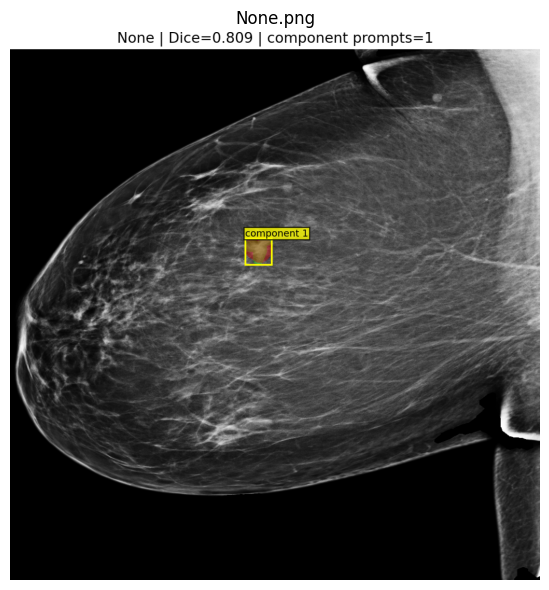

In [17]:
# Preview a few overlays.
preview_paths = sorted(OVERLAY_OUT_DIR.glob("*.png"))[:6]
if not preview_paths:
    print("No overlays generated yet.")
else:
    fig, axes = plt.subplots(len(preview_paths), 1, figsize=(9, 6 * len(preview_paths)))
    if len(preview_paths) == 1:
        axes = [axes]
    for ax, path in zip(axes, preview_paths):
        ax.imshow(io.imread(path))
        ax.set_title(path.name)
        ax.set_axis_off()
    plt.tight_layout()